In [ ]:
! pip install --quiet anndata mudata scvi-colab
from scvi_colab import install
install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


# Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import mudata as mu
import scvi
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scvi.module.base import BaseModuleClass, LossOutput
import scanpy as sc
RANDOM_SEED = 42

# Simulate data

Same setup as the main notebook. We wrap everything in MuData/AnnData instead of raw tensors.

TODO: make components in `z` orthogonal to each other (use scipy `ortho_group`)

In [ ]:
def simulate_mudata(seed=42, n=5000, noise=0.0):
    torch.manual_seed(seed)
    p1, p2, p3, k = 50, 80, 30, 2

    # true latent scores for all cells
    z = torch.normal(0, 1, size=(n, k))

    # sparse version: first half only has component 1, second half only component 2
    z_sp = z.clone()

    # uncomment for sparsity
    #z_sp[:2500, 0] = 0
    #z_sp[2500:, 1] = 0

    # random loading matrices (true weights, not learned)
    w1 = torch.randn(p1, k)
    w2 = torch.randn(p2, k)
    w3 = torch.randn(p3, k)

    # generate each block as linear combination of latent scores + noise
    x1 = z_sp @ w1.T + noise * torch.randn(n, p1)
    x2 = z_sp @ w2.T + noise * torch.randn(n, p2)
    x3 = z_sp @ w3.T + noise * torch.randn(n, p3)

    idx = np.arange(n)
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=seed)
    split = np.array(['train'] * n)
    split[te_idx] = 'test'

    # wrap each block in AnnData — rows are cells, cols are features
    def make_adata(X, name):
        adata = ad.AnnData(X=X.numpy())
        adata.obs['split'] = split
        adata.var_names = [f'{name}_{i}' for i in range(X.shape[1])]
        return adata

    mod1 = make_adata(x1, 'rna')
    mod2 = make_adata(x2, 'atac')
    mod3 = make_adata(x3, 'prot')

    # target y stored in obsm so it travels with the data object
    mod1.obsm['y'] = z_sp.numpy()

    mdata = mu.MuData({'rna': mod1, 'atac': mod2, 'prot': mod3})
    return mdata

# sMBPLS Module

Core model logic. Inherits from BaseModuleClass to fit the scvi module interface.

In [ ]:
def soft_threshold(x, lam):
    # zero out weights smaller than lam, shrink the rest toward zero
    if lam <= 0:
        return x
    return torch.sign(x) * torch.clamp(torch.abs(x) - lam, min=0.0)


class SMBPLSModule(BaseModuleClass):
    def __init__(self, n_input_per_mod, n_output=2, n_components=2, lam_w=0.05, lam_t=0.0):
        super().__init__()
        self.mod_names = list(n_input_per_mod.keys())
        self.K = n_components
        self.lam_w = lam_w
        self.lam_t = lam_t
        alpha = 1.0 / len(self.mod_names)  # equal block weights by default
        self.alpha = {m: alpha for m in self.mod_names}

        # one linear projection per modality: (n, p_b) -> (n, K)
        # no bias — these are PLS-style loadings, not a full NN layer
        self.proj = nn.ModuleDict({
            m: nn.Linear(n_input_per_mod[m], self.K, bias=False)
            for m in self.mod_names
        })

        # regression head maps latent scores to the outcome
        self.regressor = nn.Linear(self.K, n_output, bias=True)

        for m in self.mod_names:
            nn.init.normal_(self.proj[m].weight, std=0.02)
        nn.init.zeros_(self.regressor.bias)

    @torch.no_grad()
    def apply_sparsity(self):
        # proximal L1 step on loadings — called periodically during training
        for m in self.mod_names:
            W = self.proj[m].weight
            W.copy_(soft_threshold(W, self.lam_w))

    def _get_inference_input(self, tensors):
        return {m: tensors[m] for m in self.mod_names}

    def _get_generative_input(self, tensors, inference_outputs):
        return {'t': inference_outputs['t']}

    def inference(self, **block_data):
        # compute composite latent score t from all blocks
        t = None
        for m in self.mod_names:
            tb = self.proj[m](block_data[m])
            t = tb * self.alpha[m] if t is None else t + tb * self.alpha[m]

        # optional observation-level sparsity (zeroes out inactive cells)
        if self.lam_t > 0:
            t = soft_threshold(t, self.lam_t)
        return {'t': t}

    def generative(self, t):
        y_hat = self.regressor(t)
        return {'y_hat': y_hat}

    def loss(self, tensors, inference_outputs, generative_outputs):
        y = tensors['y'].float() if isinstance(tensors['y'], torch.Tensor) else torch.tensor(tensors['y'], dtype=torch.float32)
        y_hat = generative_outputs['y_hat']
        t = inference_outputs['t']

        # main regression loss
        mse = F.mse_loss(y_hat, y)

        # covariance objective (PLS-style)
        T = t - t.mean(0)
        yc = y - y.mean(0)
        cov = (T.T @ yc) / (T.shape[0] - 1)
        cov_loss = -(cov ** 2).sum() / (T.shape[1] * y.shape[1])

        # orthogonality constraint on latent scores
        Tn = T / (T.norm(dim=0, keepdim=True) + 1e-8)
        I = torch.eye(self.K, device=T.device)
        orth_loss = torch.norm(Tn.T @ Tn - I, p="fro") ** 2

        loss = mse + 0.1 * cov_loss + 0.1 * orth_loss

        return LossOutput(loss=loss, n_obs_minibatch=t.shape[0])


## SMBPLS Classifier Module
same core idea as regression model, but use cross-entropy loss instead of MSE.

In [ ]:
class SMBPLSClassifierModule(BaseModuleClass):
    def __init__(self, n_input_per_mod, n_classes, n_components=2, lam_w=0.05, lam_t=0.0):
        super().__init__()
        self.mod_names = list(n_input_per_mod.keys())
        self.K = n_components
        self.lam_w = lam_w
        self.lam_t = lam_t
        alpha = 1.0 / len(self.mod_names) # equal block weights by default
        self.alpha = {m: alpha for m in self.mod_names}

        # one linear projection per modality: (n, p_b) -> (n, K)
        self.proj = nn.ModuleDict({
            m: nn.Linear(n_input_per_mod[m], self.K, bias=False)
            for m in self.mod_names
        })

        # regression head now maps latent scores to n_classes (logits)
        self.regressor = nn.Linear(self.K, n_classes, bias=True)

        for m in self.mod_names:
            nn.init.normal_(self.proj[m].weight, std=0.02)
        nn.init.zeros_(self.regressor.bias)

    @torch.no_grad()
    def apply_sparsity(self):
        # proximal L1 step on loadings — called periodically during training
        for m in self.mod_names:
            W = self.proj[m].weight
            W.copy_(soft_threshold(W, self.lam_w))

    def _get_inference_input(self, tensors):
        return {m: tensors[m] for m in self.mod_names}

    def _get_generative_input(self, tensors, inference_outputs):
        return {'t': inference_outputs['t']}

    def inference(self, **block_data):
        # compute composite latent score t from all blocks
        t = None
        for m in self.mod_names:
            tb = self.proj[m](block_data[m])
            t = tb * self.alpha[m] if t is None else t + tb * self.alpha[m]

        # optional observation-level sparsity (zeroes out inactive cells)
        if self.lam_t > 0:
            t = soft_threshold(t, self.lam_t)
        return {'t': t}

    def generative(self, t):
        # Output logits for classification
        logits = self.regressor(t)
        return {'logits': logits}

    def loss(self, tensors, inference_outputs, generative_outputs):
        # Assuming 'y' in tensors is one-hot encoded or similar for multi-class target
        y_onehot = tensors['y'].float() if isinstance(tensors['y'], torch.Tensor) else torch.tensor(tensors['y'], dtype=torch.float32)
        y_true_labels = torch.argmax(y_onehot, dim=1) # Convert one-hot to class indices for F.cross_entropy
        logits = generative_outputs['logits']
        t = inference_outputs['t']

        # Main classification loss: Cross-entropy
        classification_loss = F.cross_entropy(logits, y_true_labels)

        # Covariance objective (PLS-style) - using the one-hot target for consistency
        T = t - t.mean(0)
        yc = y_onehot - y_onehot.mean(0) # Keep using the original y for covariance
        cov = (T.T @ yc) / (T.shape[0] - 1)
        cov_loss = -(cov ** 2).sum() / (T.shape[1] * y_onehot.shape[1])

        # Orthogonality constraint on latent scores
        Tn = T / (T.norm(dim=0, keepdim=True) + 1e-8)
        I = torch.eye(self.K, device=T.device)
        orth_loss = torch.norm(Tn.T @ Tn - I, p="fro") ** 2

        # Combine losses
        loss = classification_loss + 0.1 * cov_loss + 0.1 * orth_loss

        return LossOutput(loss=loss, n_obs_minibatch=t.shape[0])

# SMBPLS model class

User-facing class similar to how you would use scvi.model.SCVI.
Handles setup_mudata, train, get_latent_representation, and get_loadings.

In [ ]:
class SMBPLS:
    """
    Sparse Multi-Block PLS for multi-omics MuData.

    Usage
    -----
    SMBPLS.setup_mudata(mdata, modalities=['rna', 'atac', 'prot'], y_obsm_key='y', y_mod='rna')
    model = SMBPLS(mdata, n_components=2, lam_w=0.05)
    model.train(max_epochs=300)
    z = model.get_latent_representation()
    loadings = model.get_loadings()
    """

    def __init__(self, mdata, n_outputs=2, n_components=2, lam_w=0.05, lam_t=0.0):
        self.mdata = mdata
        n_input = {m: mdata[m].n_vars for m in mdata.mod_names}
        self.module = SMBPLSModule(
            n_input_per_mod=n_input,
            n_output=n_outputs,
            n_components=n_components,
            lam_w=lam_w,
            lam_t=lam_t,
        )

    @classmethod
    def setup_mudata(cls, mdata, modalities, y_obsm_key='y', y_mod='rna'):
        # store config on the mdata object so the model can find it later
        mdata.uns['smbpls_modalities'] = modalities
        mdata.uns['smbpls_y_mod'] = y_mod
        mdata.uns['smbpls_y_key'] = y_obsm_key
        print(f"Registered modalities: {modalities}, target: {y_mod}.obsm['{y_obsm_key}']")

    def train(self, max_epochs=300, lr=1e-3, batch_size=256, sparsity_freq=50):
        mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        y_mod = mdata.uns['smbpls_y_mod']
        y_key = mdata.uns['smbpls_y_key']

        # build tensors from mudata — multi-block batching is custom so we skip scvi's dataloader
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}
        y = torch.tensor(mdata[y_mod].obsm[y_key], dtype=torch.float32)

        n = y.shape[0]
        idx = np.arange(n)
        tr, te = train_test_split(idx, test_size=0.2, random_state=42)

        X_tr = {m: X_blocks[m][tr] for m in mods}
        X_te = {m: X_blocks[m][te] for m in mods}
        y_tr, y_te = y[tr], y[te]

        opt = torch.optim.Adam(self.module.parameters(), lr=lr)
        self._train_losses, self._val_losses = [], []

        self.module.train()
        for epoch in range(max_epochs):
            perm = torch.randperm(len(tr))
            epoch_loss = 0.0
            n_batches = 0
            for start in range(0, len(tr), batch_size):
                batch_idx = perm[start:start + batch_size]
                Xb = {m: X_tr[m][batch_idx] for m in mods}
                yb = y_tr[batch_idx]

                opt.zero_grad()
                inf = self.module.inference(**Xb)
                gen = self.module.generative(inf['t'])
                loss_out = self.module.loss({'y': yb}, inf, gen)
                loss_out.loss.backward()
                opt.step()
                epoch_loss += loss_out.loss.item()
                n_batches += 1

            if epoch % sparsity_freq == 0:
                self.module.apply_sparsity()

            avg_loss = epoch_loss / n_batches
            self._train_losses.append(avg_loss)

            if epoch % 50 == 0:
                self.module.eval()
                with torch.no_grad():
                    inf_te = self.module.inference(**X_te)
                    gen_te = self.module.generative(inf_te['t'])
                    val_mse = F.mse_loss(gen_te['y_hat'], y_te).item()
                self._val_losses.append((epoch, val_mse))
                print(f'epoch {epoch:>4} | train loss {avg_loss:.4f} | val MSE {val_mse:.4f}')
                self.module.train()

        self.is_trained_ = True
        print('Training done.')

    @torch.no_grad()
    def get_latent_representation(self, mdata=None):
        if mdata is None:
            mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}

        self.module.eval()
        inf = self.module.inference(**X_blocks)
        T = inf['t'].numpy()

        # store so scanpy/muon can pick it up directly from obsm
        mdata.obsm['X_smbpls'] = T
        print(f"Latent scores stored in mdata.obsm['X_smbpls'], shape {T.shape}")
        return T

    @torch.no_grad()
    def get_loadings(self):
        mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        loadings = {}
        for m in mods:
            W = self.module.proj[m].weight.numpy()  # shape (K, p_b)
            var_names = mdata[m].var_names.tolist()
            df = pd.DataFrame(W.T, index=var_names,
                              columns=[f'component_{k+1}' for k in range(self.module.K)])
            loadings[m] = df
        return loadings

    def save(self, path):
        torch.save(self.module.state_dict(), path)
        print(f'Model weights saved to {path}')

    def load(self, path):
        self.module.load_state_dict(torch.load(path))
        print(f'Model weights loaded from {path}')

    def plot_training(self):
        plt.figure()
        plt.plot(self._train_losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training loss')
        plt.show()

In [ ]:
class SMBPLSClassifier:
    """
    Sparse Multi-Block PLS for multi-omics MuData for Classification.

    Usage
    -----
    SMBPLSClassifier.setup_mudata(mdata, modalities=['rna'], y_obsm_key='stage_onehot', y_mod='rna')
    model = SMBPLSClassifier(mdata, n_classes=n_classes, n_components=5, lam_w=0.01)
    model.train(max_epochs=200)
    predicted_labels = model.predict()
    """

    def __init__(self, mdata, n_classes, n_components=2, lam_w=0.05, lam_t=0.0):
        self.mdata = mdata
        n_input = {m: mdata[m].n_vars for m in mdata.mod_names}
        self.module = SMBPLSClassifierModule(
            n_input_per_mod=n_input,
            n_classes=n_classes,
            n_components=n_components,
            lam_w=lam_w,
            lam_t=lam_t,
        )

    @classmethod
    def setup_mudata(cls, mdata, modalities, y_obsm_key, y_mod):
        # store config on the mdata object so the model can find it later
        mdata.uns['smbpls_modalities'] = modalities
        mdata.uns['smbpls_y_mod'] = y_mod
        mdata.uns['smbpls_y_key'] = y_obsm_key
        print(f"Registered modalities: {modalities}, target: {y_mod}.obsm['{y_obsm_key}']")

    def train(self, max_epochs=300, lr=1e-3, batch_size=256, sparsity_freq=50):
        mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        y_mod = mdata.uns['smbpls_y_mod']
        y_key = mdata.uns['smbpls_y_key']

        # build tensors from mudata
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}
        y = torch.tensor(mdata[y_mod].obsm[y_key], dtype=torch.float32) # y is one-hot encoded

        n = y.shape[0]
        idx = np.arange(n)
        tr, te = train_test_split(idx, test_size=0.2, random_state=42)

        X_tr = {m: X_blocks[m][tr] for m in mods}
        X_te = {m: X_blocks[m][te] for m in mods}
        y_tr, y_te = y[tr], y[te]

        opt = torch.optim.Adam(self.module.parameters(), lr=lr)
        self._train_losses, self._val_metrics = [], []

        self.module.train()
        for epoch in range(max_epochs):
            perm = torch.randperm(len(tr))
            epoch_loss = 0.0
            n_batches = 0
            for start in range(0, len(tr), batch_size):
                batch_idx = perm[start:start + batch_size]
                Xb = {m: X_tr[m][batch_idx] for m in mods}
                yb = y_tr[batch_idx]

                opt.zero_grad()
                inf = self.module.inference(**Xb)
                gen = self.module.generative(inf['t'])
                loss_out = self.module.loss({'y': yb}, inf, gen)
                loss_out.loss.backward()
                opt.step()
                epoch_loss += loss_out.loss.item()
                n_batches += 1

            if epoch % sparsity_freq == 0:
                self.module.apply_sparsity()

            avg_loss = epoch_loss / n_batches
            self._train_losses.append(avg_loss)

            if epoch % 50 == 0:
                self.module.eval()
                with torch.no_grad():
                    inf_te = self.module.inference(**X_te)
                    gen_te = self.module.generative(inf_te['t'])

                    # Calculate accuracy for classification
                    y_true_labels_te = torch.argmax(y_te, dim=1)
                    predicted_labels_te = torch.argmax(gen_te['logits'], dim=1)
                    val_accuracy = (predicted_labels_te == y_true_labels_te).float().mean().item()

                self._val_metrics.append((epoch, val_accuracy))
                print(f'epoch {epoch:>4} | train loss {avg_loss:.4f} | val accuracy {val_accuracy:.4f}')
                self.module.train()

        self.is_trained_ = True
        print('Training done.')

    @torch.no_grad()
    def get_latent_representation(self, mdata=None):
        if mdata is None:
            mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}

        self.module.eval()
        inf = self.module.inference(**X_blocks)
        T = inf['t'].numpy()

        # store so scanpy/muon can pick it up directly from obsm
        mdata.obsm['X_smbpls'] = T
        print(f"Latent scores stored in mdata.obsm['X_smbpls'], shape {T.shape}")
        return T

    @torch.no_grad()
    def predict(self, mdata=None):
        if mdata is None:
            mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        X_blocks = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}

        self.module.eval()
        inf = self.module.inference(**X_blocks)
        gen = self.module.generative(inf['t'])

        # Return predicted class indices
        predicted_logits = gen['logits']
        predicted_classes = torch.argmax(predicted_logits, dim=1).numpy()
        return predicted_classes

    @torch.no_grad()
    def get_loadings(self):
        mdata = self.mdata
        mods = mdata.uns['smbpls_modalities']
        loadings = {}
        for m in mods:
            W = self.module.proj[m].weight.numpy()  # shape (K, p_b)
            var_names = mdata[m].var_names.tolist()
            df = pd.DataFrame(W.T, index=var_names,
                              columns=[f'component_{k+1}' for k in range(self.module.K)])
            loadings[m] = df
        return loadings

    def save(self, path):
        torch.save(self.module.state_dict(), path)
        print(f'Model weights saved to {path}')

    def load(self, path):
        self.module.load_state_dict(torch.load(path))
        print(f'Model weights loaded from {path}')

    def plot_training(self):
        plt.figure()
        epochs, accuracies = zip(*self._val_metrics)
        plt.plot(epochs, accuracies, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Validation Accuracy during Training')
        plt.legend()
        plt.show()


# Run the model

MuData object with n_obs × n_vars = 5000 × 160
  3 modalities
    rna:	5000 x 50
      obs:	'split'
      obsm:	'y'
    atac:	5000 x 80
      obs:	'split'
    prot:	5000 x 30
      obs:	'split'
Registered modalities: ['rna', 'atac', 'prot'], target: rna.obsm['y']


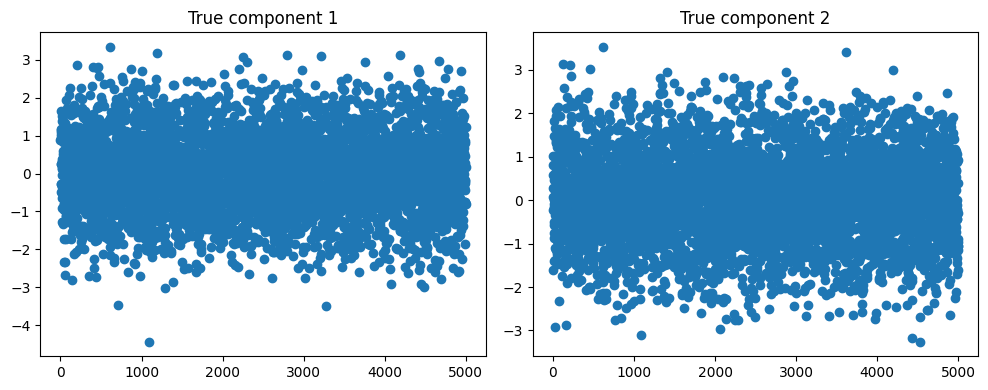

epoch    0 | train loss 0.9444 | val MSE 0.9307
epoch   50 | train loss -12.2606 | val MSE 0.0001
epoch  100 | train loss -91.8183 | val MSE 0.0000
epoch  150 | train loss -219.8846 | val MSE 0.0000
epoch  200 | train loss -384.5079 | val MSE 0.0000
epoch  250 | train loss -583.8588 | val MSE 0.0000
epoch  300 | train loss -811.4960 | val MSE 0.0000
epoch  350 | train loss -1066.8352 | val MSE 0.0000
epoch  400 | train loss -1353.6936 | val MSE 0.0001
epoch  450 | train loss -1672.1693 | val MSE 0.0000
Training done.


In [ ]:
mdata = simulate_mudata()
print(mdata)
SMBPLS.setup_mudata(mdata, modalities=['rna', 'atac', 'prot'], y_obsm_key='y', y_mod='rna')

Z = mdata['rna'].obsm['y']
n_cells = Z.shape[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
  ax.scatter(range(n_cells), Z[:,i])
  ax.set_title(f"True component {i+1}")
plt.tight_layout()
plt.show()

model = SMBPLS(mdata, n_components=2, lam_w=0.0, lam_t = 0.0)
model.train(max_epochs=500, lr=5e-4, batch_size=256)

# Latent scores

Latent scores stored in mdata.obsm['X_smbpls'], shape (5000, 2)


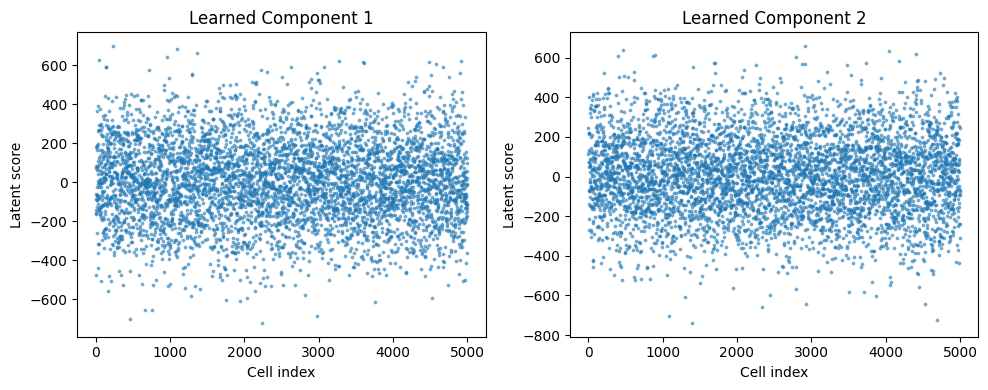

In [ ]:
T = model.get_latent_representation()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(np.arange(len(T)), T[:, i], s=3, alpha=0.5)
    ax.set_title(f'Learned Component {i+1}')
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Latent score')
plt.tight_layout()
plt.show()

Latent scores stored in mdata.obsm['X_smbpls'], shape (5000, 2)
Correlation Between Z_true and latent components T: 
[[-0.74585523  0.80619982]
 [ 0.67369474  0.5833744 ]]


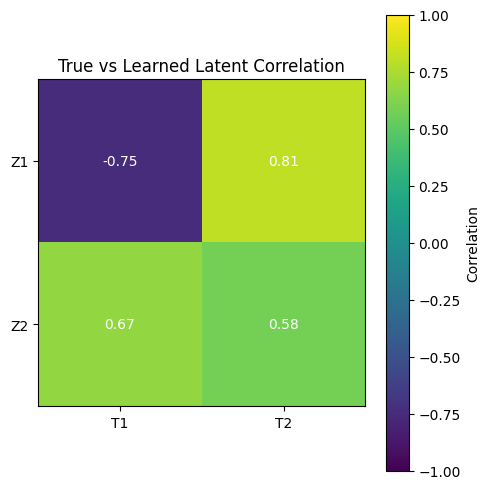

In [ ]:
Z_true = mdata["rna"].obsm["y"]
T = model.get_latent_representation()

print('Correlation Between Z_true and latent components T: ')
C = np.corrcoef(Z_true.T, T.T)[:2, 2:]
print(C)
fig, ax = plt.subplots(figsize=(5,5))

im = ax.imshow(C, vmin=-1, vmax=1)

# axis labels
ax.set_xticks(range(C.shape[1]))
ax.set_yticks(range(C.shape[0]))
ax.set_xticklabels(["T1", "T2"])
ax.set_yticklabels(["Z1", "Z2"])

# write numbers in cells
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f"{C[i,j]:.2f}",
                ha="center", va="center",
                color="white" if abs(C[i,j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, label="Correlation")
plt.title("True vs Learned Latent Correlation")

plt.tight_layout()
plt.show()


# Loadings — which features got selected per modality

rna: [50 50] non-zero loadings per component
atac: [80 80] non-zero loadings per component
prot: [30 30] non-zero loadings per component


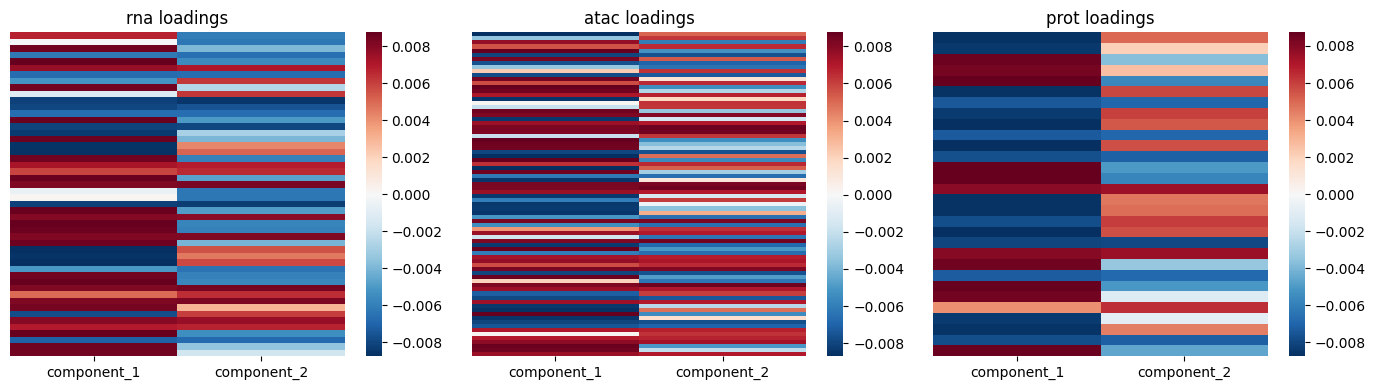

In [ ]:
loadings = model.get_loadings()

for mod_name, df in loadings.items():
    n_nonzero = (df.abs() > 1e-6).sum()
    print(f'{mod_name}: {n_nonzero.values} non-zero loadings per component')

import seaborn as sns
fig, axes = plt.subplots(1, len(loadings), figsize=(14, 4))
for ax, (mod_name, df) in zip(axes, loadings.items()):
    mask = (df.abs() > 1e-6).any(axis=1)
    sub = df[mask]
    if sub.shape[0] == 0:
        sub = df
    sns.heatmap(sub, ax=ax, center=0, cmap='RdBu_r', yticklabels=False)
    ax.set_title(f'{mod_name} loadings')
plt.tight_layout()
plt.show()

# Predicted vs true latent scores

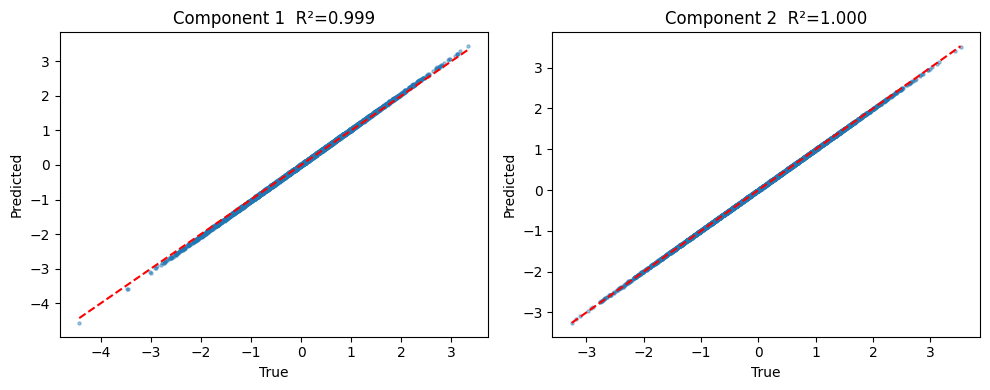

In [ ]:
mods = mdata.uns['smbpls_modalities']
y_mod = mdata.uns['smbpls_y_mod']
y_key = mdata.uns['smbpls_y_key']

X_all = {m: torch.tensor(mdata[m].X, dtype=torch.float32) for m in mods}
y_all = mdata[y_mod].obsm[y_key]

model.module.eval()
with torch.no_grad():
    inf = model.module.inference(**X_all)
    gen = model.module.generative(inf['t'])
    y_hat = gen['y_hat'].numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(y_all[:, i], y_hat[:, i], s=5, alpha=0.4)
    mn, mx = y_all[:, i].min(), y_all[:, i].max()
    ax.plot([mn, mx], [mn, mx], 'r--')
    r2 = r2_score(y_all[:, i], y_hat[:, i])
    ax.set_title(f'Component {i+1}  R²={r2:.3f}')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import torch

# Assuming y_all and y_hat are already computed from the SMBPLS model
# y_all is Z_true (the true latent scores from simulate_mudata)
# y_hat is gen['y_hat'].numpy() (SMBPLS model predictions)

# Apply soft thresholding to y_hat
lam_threshold = 0.05 # Using a reasonable lambda for thresholding, similar to MBPLS example
y_hat_thresholded = soft_threshold(torch.tensor(y_hat), lam=lam_threshold).numpy()

print(f"\n--- SMBPLS Model Metrics (after soft-thresholding y_hat with lambda={lam_threshold}) ---")

# Metrics for Component 0 of SMBPLS (Positive if true latent score is 0)
true_comp0_binary = (y_all[:, 0] == 0).astype(int)
pred_comp0_binary = (y_hat_thresholded[:, 0] == 0).astype(int)

tn0_smbpls, fp0_smbpls, fn0_smbpls, tp0_smbpls = confusion_matrix(true_comp0_binary, pred_comp0_binary, labels=[0, 1]).ravel()

print("\nComponent 0 (Positive if true latent score is 0):")
print(f"  True Positives (TP): {tp0_smbpls}")
print(f"  True Negatives (TN): {tn0_smbpls}")
print(f"  False Positives (FP): {fp0_smbpls}")
print(f"  False Negatives (FN): {fn0_smbpls}")

specificity0 = tn0_smbpls / (tn0_smbpls + fp0_smbpls) if (tn0_smbpls + fp0_smbpls) > 0 else 0
sensitivity0 = tp0_smbpls / (tp0_smbpls + fn0_smbpls) if (tp0_smbpls + fn0_smbpls) > 0 else 0
print(f"  Specificity: {specificity0:.4f}")
print(f"  Sensitivity: {sensitivity0:.4f}")

# Metrics for Component 1 of SMBPLS (Positive if true latent score is 0)
true_comp1_binary = (y_all[:, 1] == 0).astype(int)
pred_comp1_binary = (y_hat_thresholded[:, 1] == 0).astype(int)

tn1_smbpls, fp1_smbpls, fn1_smbpls, tp1_smbpls = confusion_matrix(true_comp1_binary, pred_comp1_binary, labels=[0, 1]).ravel()

print("\nComponent 1 (Positive if true latent score is 0):")
print(f"  True Positives (TP): {tp1_smbpls}")
print(f"  True Negatives (TN): {tn1_smbpls}")
print(f"  False Positives (FP): {fp1_smbpls}")
print(f"  False Negatives (FN): {fn1_smbpls}")

specificity1 = tn1_smbpls / (tn1_smbpls + fp1_smbpls) if (tn1_smbpls + fp1_smbpls) > 0 else 0
sensitivity1 = tp1_smbpls / (tp1_smbpls + fn1_smbpls) if (tp1_smbpls + fn1_smbpls) > 0 else 0
print(f"  Specificity: {specificity1:.4f}")
print(f"  Sensitivity: {sensitivity1:.4f}")


--- SMBPLS Model Metrics (after soft-thresholding y_hat with lambda=0.05) ---

Component 0 (Positive if true latent score is 0):
  True Positives (TP): 2500
  True Negatives (TN): 2406
  False Positives (FP): 94
  False Negatives (FN): 0
  Specificity: 0.9624
  Sensitivity: 1.0000

Component 1 (Positive if true latent score is 0):
  True Positives (TP): 2500
  True Negatives (TN): 2408
  False Positives (FP): 92
  False Negatives (FN): 0
  Specificity: 0.9632
  Sensitivity: 1.0000


# UMAP of latent space

Scanpy works directly with values stored in mdata.obsm.

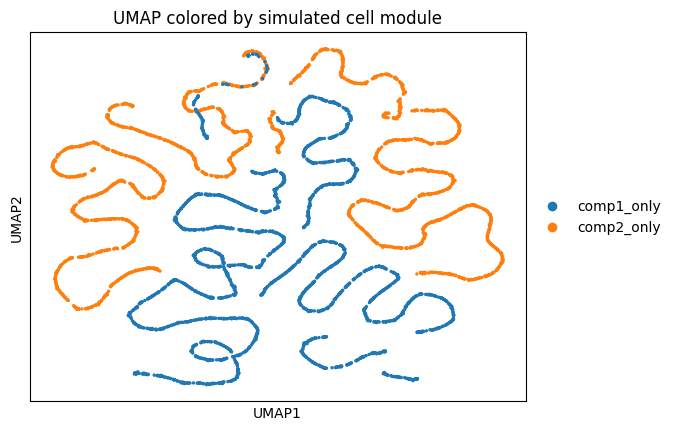

In [ ]:
# use rna modality as the reference adata for scanpy
adata_ref = mdata['rna'].copy()
adata_ref.obsm['X_smbpls'] = T

sc.pp.neighbors(adata_ref, use_rep='X_smbpls', n_neighbors=15)
sc.tl.umap(adata_ref)

# color by which latent component is active — matches our simulated structure
adata_ref.obs['active_component'] = 'both'
adata_ref.obs.loc[adata_ref.obs.index[:2500], 'active_component'] = 'comp2_only'
adata_ref.obs.loc[adata_ref.obs.index[2500:], 'active_component'] = 'comp1_only'

sc.pl.umap(adata_ref, color='active_component', title='UMAP colored by simulated cell module')

# Training curve

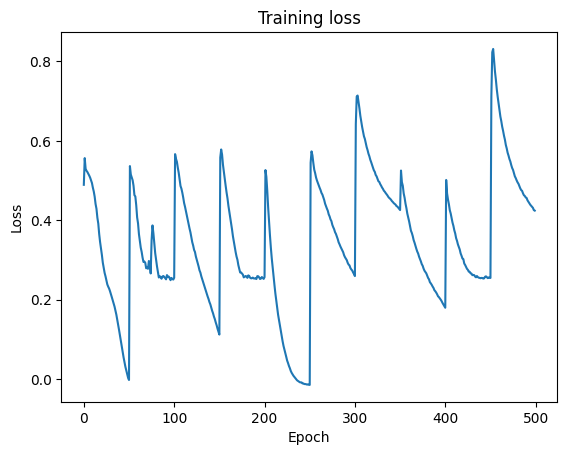

In [ ]:
model.plot_training()

# Save and reload model weights

In [ ]:
model.save('smbpls_weights_simulation.pt')

# to reload later:
model2 = SMBPLS(mdata, n_components=2, lam_w=0.05)
model2.load('smbpls_weights_simulation.pt')

Model weights saved to smbpls_weights_simulation.pt
Model weights loaded from smbpls_weights_simulation.pt


Latent scores stored in mdata.obsm['X_smbpls'], shape (5000, 2)


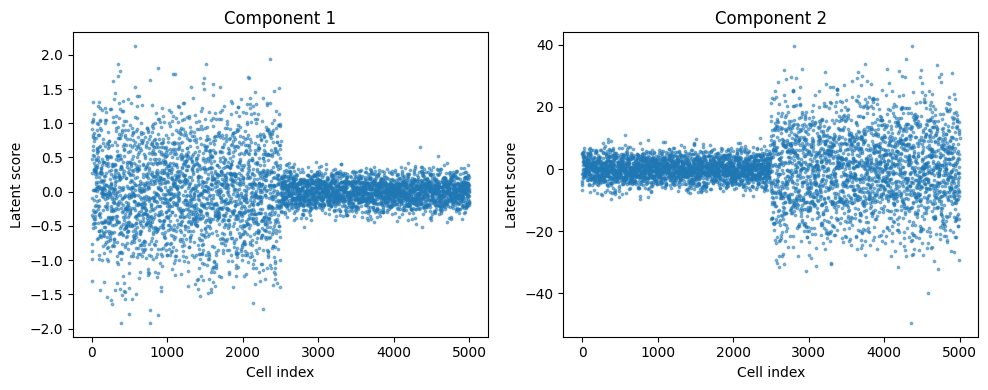

In [ ]:
T = model2.get_latent_representation()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(np.arange(len(T)), T[:, i], s=3, alpha=0.5)
    ax.set_title(f'Component {i+1}')
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Latent score')
plt.tight_layout()
plt.show()

## Compare against traditional mutliblock

In [ ]:
! pip install mbpls

In [ ]:
from mbpls.mbpls import MBPLS

# Extract data from mdata for MBPLS
X_mbpls_blocks = []
modalities = ['rna', 'atac', 'prot']
for mod_name in modalities:
    X_mbpls_blocks.append(mdata[mod_name].X)

y_mbpls = mdata['rna'].obsm['y']

# Initialize and fit MBPLS model
# Using 2 components to match the SMBPLS model for comparison
mbpls_mdata = MBPLS(n_components=2)
mbpls_mdata.fit(X_mbpls_blocks, y_mbpls)

print("MBPLS model fitted to mdata.")
# Predict using the fitted MBPLS model
y_pred_mbpls = mbpls_mdata.predict(X_mbpls_blocks)
print(f"Predicted y shape: {y_pred_mbpls.shape}")

# Calculate R2 score
r2_mbpls = r2_score(y_mbpls, y_pred_mbpls)
print(f"R2 score for MBPLS prediction: {r2_mbpls:.4f}")
y_pred_thresholded = soft_threshold(torch.tensor(y_pred_mbpls), lam=0.05)
import numpy as np
from sklearn.metrics import confusion_matrix

# --- SMBPLSClassifier Metrics (Real Data) ---
# Assuming 'true_classes' and 'predicted_classes' are already computed from the real data classification
# true_classes = np.argmax(y_true, axis=1) # Already computed from c1f9fbd8
# predicted_classes = np.argmax(y_pred, axis=1) # Already computed from c1f9fbd8
# stage_names = adata.obs['stage'].cat.categories.tolist() # Already computed from c1f9fbd8

# Define positive class as class index 0 (E6.5) for the real data classification
positive_class_index_real = 0

binary_true_real = (true_classes == positive_class_index_real).astype(int)
binary_pred_real = (predicted_classes == positive_class_index_real).astype(int)

tn_real, fp_real, fn_real, tp_real = confusion_matrix(binary_true_real, binary_pred_real, labels=[0, 1]).ravel()

print(f"SMBPLSClassifier Metrics (Positive class = Stage '{stage_names[positive_class_index_real]}'):")
print(f"  True Positives (TP): {tp_real}")
print(f"  True Negatives (TN): {tn_real}")
print(f"  False Positives (FP): {fp_real}")
print(f"  False Negatives (FN): {fn_real}")

# --- MBPLS Metrics (Simulated Data) ---
# y_mbpls is Z_true from simulated data, already available
# y_pred_thresholded is already computed

# Metrics for Component 0 of MBPLS (Positive if true latent score is 0)
true_comp0_binary = (y_mbpls[:, 0] == 0).astype(int)
pred_comp0_binary = (y_pred_thresholded[:, 0] == 0).to(int)

tn0_mbpls, fp0_mbpls, fn0_mbpls, tp0_mbpls = confusion_matrix(true_comp0_binary, pred_comp0_binary, labels=[0, 1]).ravel()

print("\nMBPLS Metrics (Component 0 - Positive if true latent score is 0):")
print(f"  True Positives (TP): {tp0_mbpls}")
print(f"  True Negatives (TN): {tn0_mbpls}")
print(f"  False Positives (FP): {fp0_mbpls}")
print(f"  False Negatives (FN): {fn0_mbpls}")

print(f'Specificity:{tn0_mbpls / (tn0_mbpls + fn0_mbpls)}')
print(f'Sensitivity: {tp0_mbpls / (tp0_mbpls + fp0_mbpls)}')

# Metrics for Component 1 of MBPLS (Positive if true latent score is 0)
true_comp1_binary = (y_mbpls[:, 1] == 0).astype(int)
pred_comp1_binary = (y_pred_thresholded[:, 1] == 0).to(int)

tn1_mbpls, fp1_mbpls, fn1_mbpls, tp1_mbpls = confusion_matrix(true_comp1_binary, pred_comp1_binary, labels=[0, 1]).ravel()

print("\nMBPLS Metrics (Component 1 - Positive if true latent score is 0):")
print(f"  True Positives (TP): {tp1_mbpls}")
print(f"  True Negatives (TN): {tn1_mbpls}")
print(f"  False Positives (FP): {fp1_mbpls}")
print(f"  False Negatives (FN): {fn1_mbpls}")

print(f'Specificity:{tn1_mbpls / (tn1_mbpls + fn1_mbpls)}')
print(f'Sensitivity: {tp1_mbpls / (tp1_mbpls + fp1_mbpls)}')

MBPLS model fitted to mdata.
Predicted y shape: (5000, 2)
R2 score for MBPLS prediction: 0.3877
SMBPLSClassifier Metrics (Positive class = Stage 'E6.5'):
  True Positives (TP): 1000
  True Negatives (TN): 86095
  False Positives (FP): 457
  False Negatives (FN): 1715

MBPLS Metrics (Component 0 - Positive if true latent score is 0):
  True Positives (TP): 1009
  True Negatives (TN): 2446
  False Positives (FP): 54
  False Negatives (FN): 1491
Specificity:0.6212852425704851
Sensitivity: 0.949200376293509

MBPLS Metrics (Component 1 - Positive if true latent score is 0):
  True Positives (TP): 1158
  True Negatives (TN): 2452
  False Positives (FP): 48
  False Negatives (FN): 1342
Specificity:0.6462836056931998
Sensitivity: 0.9601990049751243


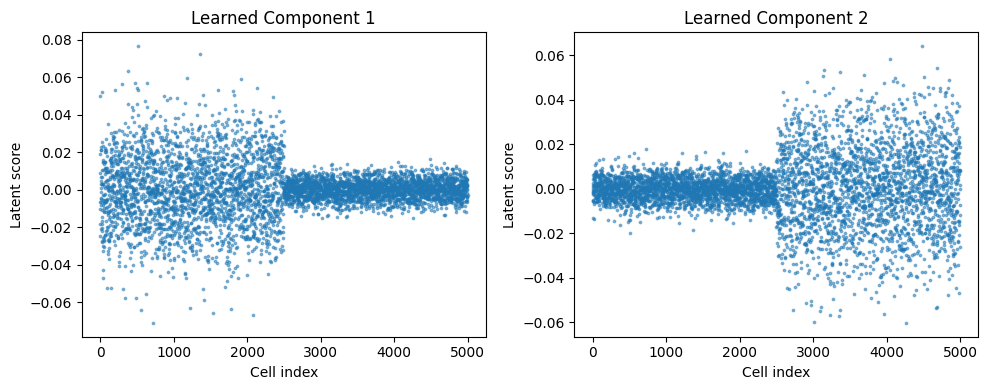

In [ ]:
T = mbpls_mdata.Ts_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.scatter(np.arange(len(T)), T[:, i], s=3, alpha=0.5)
    ax.set_title(f'Learned Component {i+1}')
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Latent score')
plt.tight_layout()
plt.show()

Running 20 simulations to collect sensitivity and specificity data for MBPLS...
Run 1/20 completed.
Run 2/20 completed.
Run 3/20 completed.
Run 4/20 completed.
Run 5/20 completed.
Run 6/20 completed.
Run 7/20 completed.
Run 8/20 completed.
Run 9/20 completed.
Run 10/20 completed.
Run 11/20 completed.
Run 12/20 completed.
Run 13/20 completed.
Run 14/20 completed.
Run 15/20 completed.
Run 16/20 completed.
Run 17/20 completed.
Run 18/20 completed.
Run 19/20 completed.
Run 20/20 completed.


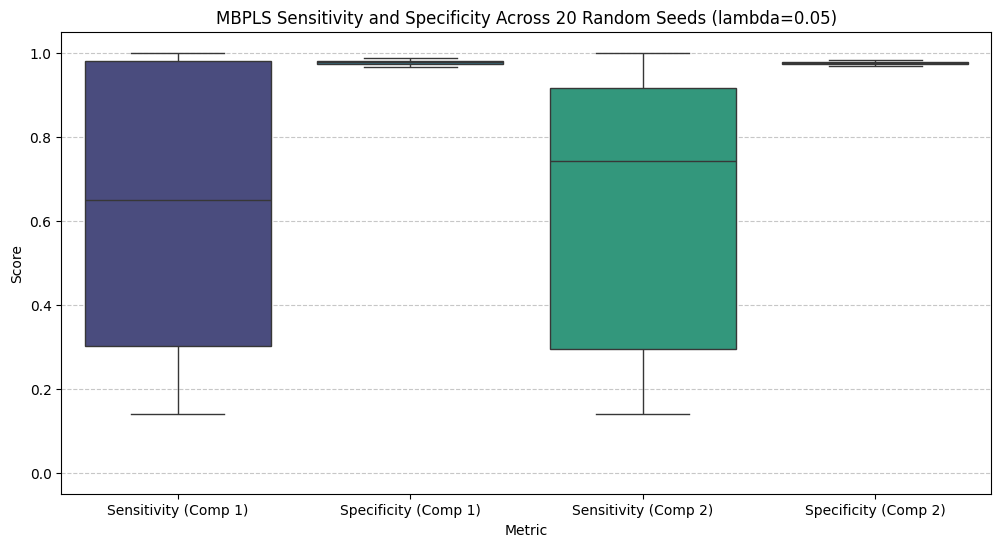

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mbpls.mbpls import MBPLS

all_sensitivities_comp0 = []
all_specificities_comp0 = []
all_sensitivities_comp1 = []
all_specificities_comp1 = []

num_runs = 20
lam_threshold_for_metrics = 0.05 # Using the same threshold as in the last execution

print(f"Running {num_runs} simulations to collect sensitivity and specificity data for MBPLS...")

for i in range(num_runs):
    seed = RANDOM_SEED + i # Varying the seed for each run

    # 1. Simulate data
    mdata_run = simulate_mudata(seed=seed)

    # Extract data for MBPLS
    X_mbpls_blocks_run = []
    modalities = ['rna', 'atac', 'prot']
    for mod_name in modalities:
        X_mbpls_blocks_run.append(mdata_run[mod_name].X)

    y_mbpls_run = mdata_run['rna'].obsm['y']

    # 2. Train MBPLS model
    mbpls_model_run = MBPLS(n_components=2)
    mbpls_model_run.fit(X_mbpls_blocks_run, y_mbpls_run)

    # 3. Get predictions
    y_pred_mbpls_run = mbpls_model_run.predict(X_mbpls_blocks_run)

    # Apply soft thresholding to y_pred_mbpls_run
    y_pred_thresholded_run = soft_threshold(torch.tensor(y_pred_mbpls_run), lam=lam_threshold_for_metrics).numpy()
    # TODO: sort ascending, get indices of lowest 2500, set to 0 and calculate specificity/sensitivity

    # 4. Calculate Sensitivity and Specificity for Component 0
    true_comp0_binary_run = (y_mbpls_run[:, 0] == 0).astype(int)
    pred_comp0_binary_run = (y_pred_thresholded_run[:, 0] == 0).astype(int)
    tn0, fp0, fn0, tp0 = confusion_matrix(true_comp0_binary_run, pred_comp0_binary_run, labels=[0, 1]).ravel()

    specificity0_run = tn0 / (tn0 + fp0) if (tn0 + fp0) > 0 else 0
    sensitivity0_run = tp0 / (tp0 + fn0) if (tp0 + fn0) > 0 else 0

    all_sensitivities_comp0.append(sensitivity0_run)
    all_specificities_comp0.append(specificity0_run)

    # 5. Calculate Sensitivity and Specificity for Component 1
    true_comp1_binary_run = (y_mbpls_run[:, 1] == 0).astype(int)
    pred_comp1_binary_run = (y_pred_thresholded_run[:, 1] == 0).astype(int)
    tn1, fp1, fn1, tp1 = confusion_matrix(true_comp1_binary_run, pred_comp1_binary_run, labels=[0, 1]).ravel()

    specificity1_run = tn1 / (tn1 + fp1) if (tn1 + fp1) > 0 else 0
    sensitivity1_run = tp1 / (tp1 + fn1) if (tp1 + fn1) > 0 else 0

    all_sensitivities_comp1.append(sensitivity1_run)
    all_specificities_comp1.append(specificity1_run)

    print(f"Run {i+1}/{num_runs} completed.")

# Prepare data for plotting
data = {
    'Metric': (['Sensitivity (Comp 1)'] * num_runs) + (['Specificity (Comp 1)'] * num_runs) +
              (['Sensitivity (Comp 2)'] * num_runs) + (['Specificity (Comp 2)'] * num_runs),
    'Value': all_sensitivities_comp0 + all_specificities_comp0 +
             all_sensitivities_comp1 + all_specificities_comp1
}
df_metrics = pd.DataFrame(data)

# Create box plots
plt.figure(figsize=(12, 6))
sns.boxplot(x='Metric', y='Value', data=df_metrics, palette='viridis')
plt.title(f'MBPLS Sensitivity and Specificity Across {num_runs} Random Seeds (lambda={lam_threshold_for_metrics})')
plt.ylabel('Score')
plt.ylim(-0.05, 1.05) # Ensure y-axis covers full range of scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Real data deployment

In [ ]:
! pip install --quiet scvelo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.2/191.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.3 MB/s eta 0:00:00


In [ ]:
from scvelo import datasets

adata = datasets.gastrulation()

  0%|          | 0.00/4.37G [00:00<?, ?B/s]

# EDA on Dataset and Stages

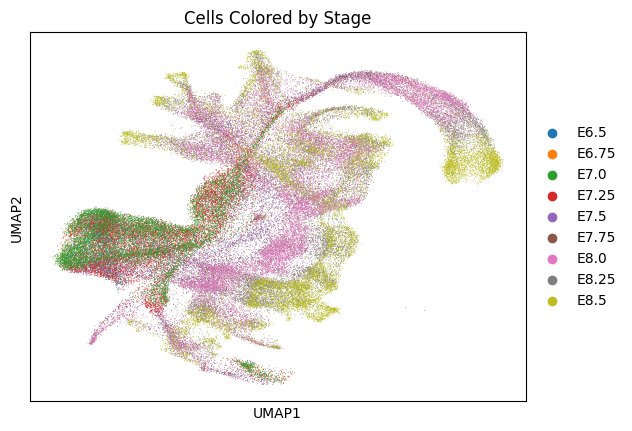

In [ ]:
sc.pl.umap(adata, color=["stage"], title='Cells Colored by Stage')

In [ ]:
mdata = mu.MuData({'rna': adata})
adata

AnnData object with n_obs × n_vars = 89267 × 53801
    obs: 'barcode', 'sample', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'cell_velocyto_loom'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'stage_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

In [ ]:
import pandas as pd
import numpy as np
import mudata as mu
import anndata as ad
from sklearn.model_selection import train_test_split

# 1. Prepare target
y_dummies = pd.get_dummies(adata.obs['stage']).astype(float).values

# 2. Train/test split
idx = np.arange(adata.n_obs)
tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=42)

split = np.array(['train'] * adata.n_obs)
split[te_idx] = 'test'

# 3. Create a single 'rna' block from PCA components
adata_rna = ad.AnnData(X=adata.obsm["X_pca"].copy())
adata_rna.obs = adata.obs.copy()
adata_rna.obs["split"] = split
adata_rna.obsm["stage_onehot"] = y_dummies

# 4. Wrap in MuData with a single 'rna' modality
mdata_real = mu.MuData({
    "rna": adata_rna
})

# 5. Setup SMBPLS for the single 'rna' modality
SMBPLSClassifier.setup_mudata(
    mdata_real,
    modalities=["rna"],
    y_obsm_key="stage_onehot",
    y_mod="rna"
)

# 6. Train
model_real = SMBPLSClassifier(
    mdata_real,
    n_classes=y_dummies.shape[1],
    n_components=5,
    lam_w=0.01
)

model_real.train(max_epochs=200, lr=1e-3, batch_size=512)

Registered modalities: ['rna'], target: rna.obsm['stage_onehot']
epoch    0 | train loss 1.8833 | val accuracy 0.3981
epoch   50 | train loss 1.0776 | val accuracy 0.5567
epoch  100 | train loss 1.0670 | val accuracy 0.5632
epoch  150 | train loss 1.0353 | val accuracy 0.5597
Training done.


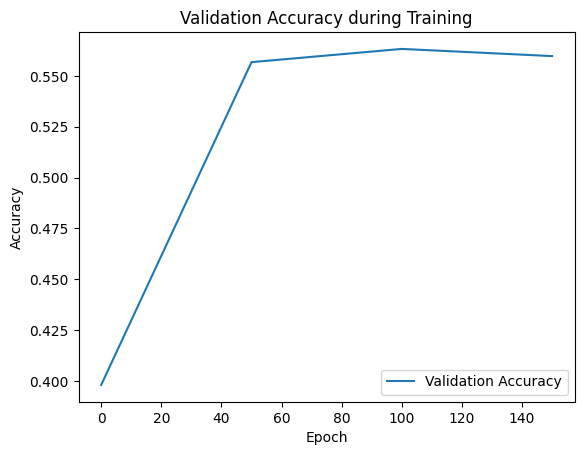

In [ ]:
model_real.plot_training()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

y_true = mdata_real['rna'].obsm['stage_onehot']

# Get the predicted one-hot encoded stages (y_hat) from the model
model_real.module.eval()
with torch.no_grad():
    # Prepare input for inference
    mods = mdata_real.uns['smbpls_modalities']
    X_all_real = {m: torch.tensor(mdata_real[m].X, dtype=torch.float32) for m in mods}

    # Perform inference and generative steps
    inf_real = model_real.module.inference(**X_all_real)
    gen_real = model_real.module.generative(inf_real['t'])
    y_pred = gen_real['logits'].numpy() # This is the correct prediction output

# Get stage names from the original adata object
stage_names = adata.obs['stage'].cat.categories.tolist()

# 1. Convert probabilities/logits to class indices
predicted_classes = np.argmax(y_pred, axis=1)
true_classes = np.argmax(y_true, axis=1)

# 2. Print Classification Report
print("Classification Report:")
clf_df = pd.DataFrame(classification_report(true_classes, predicted_classes, target_names=stage_names, output_dict=True)).transpose()
clf_df['support'] = clf_df['support'].astype(int)
clf_df['support_proportion'] = clf_df['support'] / 89267
clf_df.to_csv('classification_report.csv')
print(clf_df)

Classification Report:
              precision    recall  f1-score  support  support_proportion
E6.5           0.686342  0.368324  0.479386     2715            0.030414
E6.75          0.592814  0.201356  0.300607     1475            0.016523
E7.0           0.648479  0.816795  0.722970    11277            0.126329
E7.25          0.517065  0.556528  0.536071    10508            0.117714
E7.5           0.464264  0.314774  0.375176     7202            0.080679
E7.75          0.529897  0.354378  0.424718    10153            0.113737
E8.0           0.520401  0.622196  0.566764    14534            0.162815
E8.25          0.466700  0.437907  0.451845    15042            0.168506
E8.5           0.608717  0.693173  0.648205    16361            0.183282
accuracy       0.551066  0.551066  0.551066        0            0.000000
macro avg      0.559409  0.485048  0.500638    89267            1.000000
weighted avg   0.546120  0.551066  0.539778    89267            1.000000


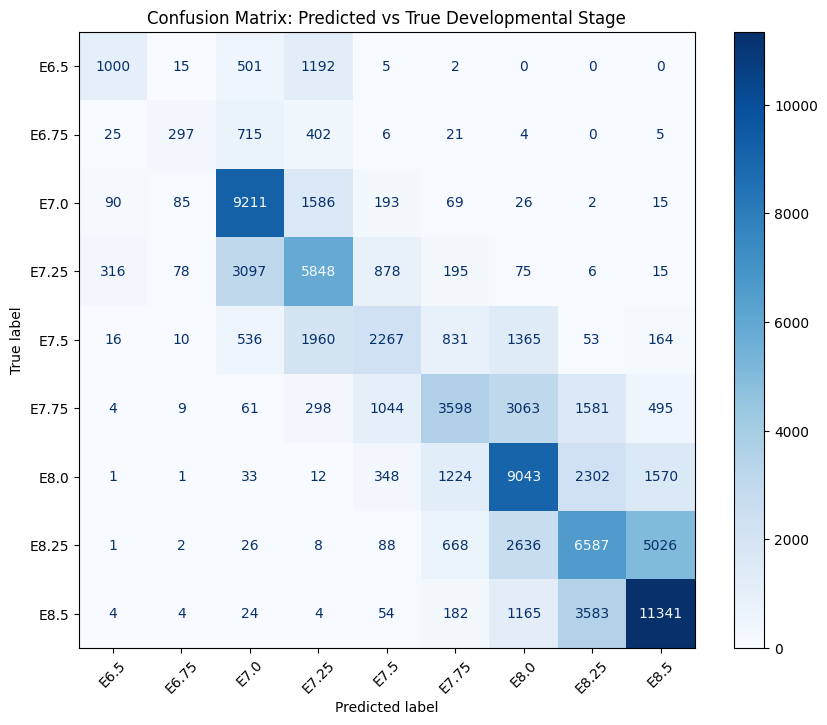

In [ ]:
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=stage_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix: Predicted vs True Developmental Stage')
plt.show()

Explanation of Results:
- **Higher Support, Better Performance**: Stages with a higher number of samples (like E8.5, E8.25, E8.0, and E7.0) provide the model with more data to learn the unique features of those classes. This often leads to better precision, recall, and F1-scores for those stages.

  - For instance, E8.5 has the highest support (16,361) and a relatively high F1-score (0.65). E7.0 also has high support (11,277) and the highest F1-score (0.72).
- **Lower Support, Poorer Performance**: Conversely, stages with fewer samples (like E6.5 with 2,715 samples and especially E6.75 with only 1,475 samples) typically show lower performance metrics (e.g., E6.75 has the lowest F1-score of 0.30).

In [ ]:
# Create an AnnData object from the real data modality for UMAP visualization
adata_real_for_umap = mdata_real['rna'].copy()

# Get latent representation from the model trained on real data
T_real = model_real.get_latent_representation(mdata=mdata_real)
adata_real_for_umap.obsm['X_smbpls'] = T_real

# Compute neighbors and UMAP for the real data
sc.pp.neighbors(adata_real_for_umap, use_rep='X_smbpls', n_neighbors=15)
sc.tl.umap(adata_real_for_umap)

# Add predicted stages to the AnnData object
adata_real_for_umap.obs['predicted_stage'] = pd.Categorical.from_codes(predicted_classes, categories=stage_names)

# Plot UMAP colored by predicted developmental stage
sc.pl.umap(adata_real_for_umap, color='predicted_stage', title='UMAP colored by Predicted Developmental Stage')

Latent scores stored in mdata.obsm['X_smbpls'], shape (89267, 5)


KeyboardInterrupt: 

TODO For Next Week:
- Test out different covariance loss terms \
  0.1 works best, along with 0.2 on orthogonality term
- Discuss orthogonality penalization vs. delfating separately
- Celltype UMAP, Embryo Date UMAP, PLS Component coloring UMAP,